<h1 style='text-align: center;'>Random Forest</h1>

<h2>Import Libraries</h2>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

<h2>Load Data</h2>

Loading data and then converting ds column to datetime type

In [2]:
df = pd.read_csv('clean_data/updt_clean_wthr_dt.csv')
df["ds"] = pd.to_datetime(df["ds"])
df = df.sort_values("ds").reset_index(drop=True)

df.head(5)

,ds,HourlyAltimeterSetting,HourlyDewPointTemperature,HourlyPrecipitation,HourlyRelativeHumidity,HourlySeaLevelPressure,HourlyStationPressure,HourlyVisibility,HourlyWetBulbTemperature,HourlyWindDirection,HourlyWindSpeed,Hourly_Dry_Bulb_Temp_F,year,month,day,hour,SOURCE,REPORT_TYPE
0,2024-01-01 00:00:00,239.955918,37.664741,0.069097,59.83137,238.854888,231.777947,10.794917,45.823099,68.31805,5.352951,52.009369,2024.0,1.0,1.0,0.0,7.0,FM-15
1,2024-01-01 01:00:00,239.895918,32.000000,0.069097,68.00000,30.030000,29.565000,9.970000,38.000000,230.00000,5.000000,42.000000,2024.0,1.0,1.0,1.0,7.0,FM-15
2,2024-01-01 02:00:00,30.020000,31.000000,0.000000,67.00000,30.020000,29.550000,10.000000,37.000000,230.00000,3.000000,41.000000,2024.0,1.0,1.0,2.0,7.0,FM-15
3,2024-01-01 03:00:00,30.030000,30.000000,0.000000,68.00000,30.020000,29.560000,10.000000,36.000000,240.00000,5.000000,40.000000,2024.0,1.0,1.0,3.0,7.0,FM-15
4,2024-01-01 04:00:00,239.885918,30.000000,0.069097,73.00000,30.010000,29.545000,9.970000,35.000000,240.00000,5.000000,38.000000,2024.0,1.0,1.0,4.0,7.0,FM-15


<h2>Filter Data</h2>

Removing dates September 17th to September 30th 2025 from the model as it needs to be hidden completely.

In [3]:
# Forecasting Dates (Needs to be hidden from model)
f_start = pd.Timestamp("2025-09-17 00:00:00")
f_end = pd.Timestamp("2025-09-30 23:59:59")

# Filter
mask = (df["ds"] >= f_start) & (df["ds"] <= f_end)
df = df.loc[~mask].copy()
df['ds'].max()

Timestamp('2025-09-16 23:00:00')

In [4]:
df["year"] = df["ds"].dt.year
df["month"] = df["ds"].dt.month
df["day"] = df["ds"].dt.day
df["hour"] = df["ds"].dt.hour

df.dtypes

ds                           datetime64[ns]
HourlyAltimeterSetting              float64
HourlyDewPointTemperature           float64
HourlyPrecipitation                 float64
HourlyRelativeHumidity              float64
HourlySeaLevelPressure              float64
HourlyStationPressure               float64
HourlyVisibility                    float64
HourlyWetBulbTemperature            float64
HourlyWindDirection                 float64
HourlyWindSpeed                     float64
Hourly_Dry_Bulb_Temp_F              float64
year                                  int32
month                                 int32
day                                   int32
hour                                  int32
SOURCE                              float64
REPORT_TYPE                          object
dtype: object

<h2>Feature Engineering</h2>

Creating Lag features as well as cyclical encoding time features

In [5]:
target = "Hourly_Dry_Bulb_Temp_F"

df["year"] = df["ds"].dt.year.astype(int)
df["month"] = df["ds"].dt.month.astype(int)
df["day"] = df["ds"].dt.day.astype(int)
df["hour"] = df["ds"].dt.hour.astype(int)
df["dayofyear"] = df["ds"].dt.dayofyear.astype(int)

# Cyclical encodings
df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24.0)
df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24.0)
df["doy_sin"]  = np.sin(2*np.pi*df["dayofyear"]/366.0)
df["doy_cos"]  = np.cos(2*np.pi*df["dayofyear"]/366.0)

base_features = ["year","month","day","hour","hour_sin","hour_cos","doy_sin","doy_cos"]

In [6]:
lag_hours = [1, 2, 3, 6, 12, 24, 48, 72, 168]
for L in lag_hours:
    df[f"lag_{L}h"] = df[target].shift(L)

lag_features = [f"lag_{L}h" for L in lag_hours]
features = base_features + lag_features

<h2>Splitting Data into Train/Test</h2>

Split data into train and test, where test is the last 2 weeks of the dataset

In [7]:
# Point at which data should be split
test_start = pd.Timestamp("2025-09-01 00:00:00")
test_end = pd.Timestamp("2025-09-16 23:59:59")

train_df = df[df["ds"] < test_start].copy()
test_df   = df[(df["ds"] >= test_start) & (df["ds"] <= test_end)].copy()

X_train = train_df[features].astype(float)
y_train = train_df[target].astype(float)

X_test = test_df[features].astype(float)
y_test = test_df[target].astype(float)

print(f"Train window : {train_df['ds'].min()} → {train_df['ds'].max()}  (rows={len(train_df)})")
print(f"Valid window : {test_df['ds'].min()} → {test_df['ds'].max()}  (rows={len(test_df)})")

Train window : 2024-01-01 00:00:00 → 2025-08-31 00:00:00  (rows=14529)
Valid window : 2025-09-01 00:00:00 → 2025-09-16 23:00:00  (rows=340)


<h2>Model Training/Hyperparameter Tuning</h2>

Perform Model training and hyperparameter tuning with cross fold validation - 5 folds

In [8]:
rf = RandomForestRegressor(random_state=0, n_jobs=-1)
    
tscv = TimeSeriesSplit(n_splits=5)
    
params = {
    "n_estimators": [300, 400, 500, 700, 900],
    "max_depth": [None, 12, 16, 20, 24, 30],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", 0.7, 1.0],
    "bootstrap": [True, False],
}
    
search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=params,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    random_state=0,
    n_jobs=-1,
    verbose=1,
    refit=True,
)
    
search.fit(X_train, y_train)
best_model = search.best_estimator_
best_cv_rmse = float(np.sqrt(-search.best_score_))
print("\nBest CV params:", search.best_params_)
print("Best CV RMSE  :", round(best_cv_rmse, 3))

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/opt/anaconda3/envs/AIPI520/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best CV params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 0.7, 'max_depth': None, 'bootstrap': False}
Best CV RMSE  : 1.594


<h2>Validation</h2>

Once model has been trained we verify to see how well it fits on the test set of the data


Validation (2025-09-01 → 2025-09-16):
RMSE: 1.995 | MAE: 1.360 | R²: 0.938


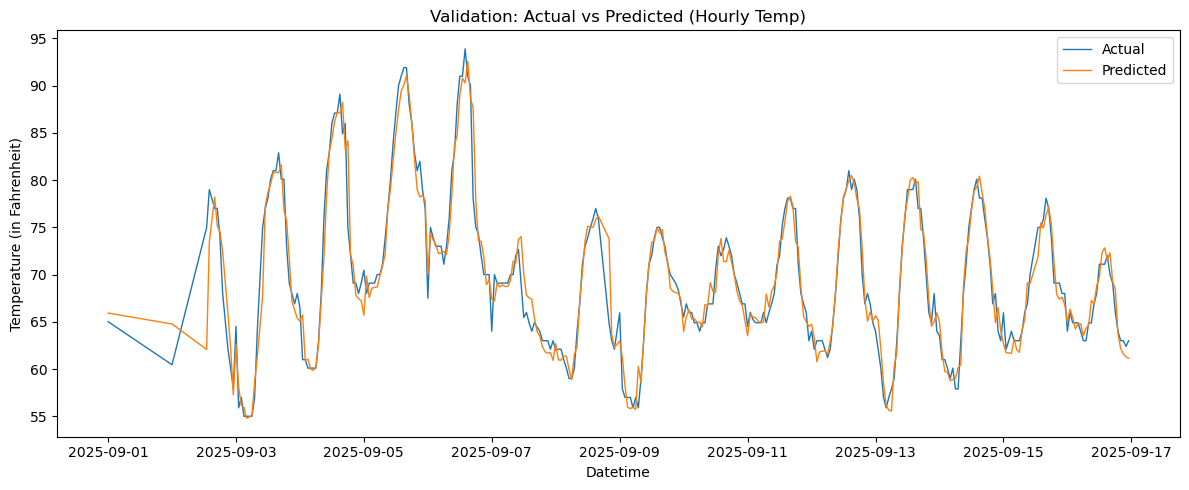

In [9]:
y_test_pred = best_model.predict(X_test)
rmse = float(np.sqrt(mean_squared_error(y_test, y_test_pred)))
mae  = float(mean_absolute_error(y_test, y_test_pred))
r2   = float(r2_score(y_test, y_test_pred))

print(f"\nValidation (2025-09-01 → 2025-09-16):")
print(f"RMSE: {rmse:.3f} | MAE: {mae:.3f} | R²: {r2:.3f}")

plt.figure(figsize=(12,5))
plt.plot(test_df["ds"], y_test.values, label="Actual", linewidth=1)
plt.plot(test_df["ds"], y_test_pred, label="Predicted", linewidth=1)
plt.title("Validation: Actual vs Predicted (Hourly Temp)")
plt.xlabel("Datetime")
plt.ylabel("Temperature (in Fahrenheit)")
plt.legend()
plt.tight_layout()
plt.show()

<h2>Predictions</h2>

Now that the best model has been found with optimal parameters, we can forecast the future temps by using the entire dataset to train on.
We also explore feature importance here.

In [10]:
f_start = pd.Timestamp("2025-09-17 00:00:00")
f_end = pd.Timestamp("2025-09-30 23:59:59")

history = train_df.set_index("ds")[target].astype(float).copy()
history = pd.concat([history, test_df.set_index("ds")[target].astype(float)]).sort_index()

future_idx = pd.date_range(f_start, f_end, freq="h", inclusive="both")

def build_feature_row(ts, hist_series):
    row = {}
    
    row["year"]  = ts.year
    row["month"] = ts.month
    row["day"]   = ts.day
    row["hour"]  = ts.hour
    doy = ts.timetuple().tm_yday
    row["hour_sin"] = np.sin(2*np.pi*ts.hour/24.0)
    row["hour_cos"] = np.cos(2*np.pi*ts.hour/24.0)
    row["doy_sin"]  = np.sin(2*np.pi*doy/366.0)
    row["doy_cos"]  = np.cos(2*np.pi*doy/366.0)
    
    for L in lag_hours:
        lag_ts = ts - pd.Timedelta(hours=L)
        row[f"lag_{L}h"] = hist_series.get(lag_ts, np.nan)
    return row

future_rows = []
for ts in future_idx:
    feat_row = build_feature_row(ts, history)
    
    x = pd.DataFrame([feat_row], columns=features).astype(float)
    y_hat = best_model.predict(x)[0]
    future_rows.append({"ds": ts, "pred_hourlyDryBulbTemperature": y_hat})
    history.loc[ts] = y_hat

predictions = pd.DataFrame(future_rows).sort_values("ds").reset_index(drop=True)

print("\nForecast sample (first 10 rows):")
print(predictions.head(10))


Forecast sample (first 10 rows):
                   ds  pred_hourlyDryBulbTemperature
0 2025-09-17 00:00:00                      62.526134
1 2025-09-17 01:00:00                      61.047262
2 2025-09-17 02:00:00                      60.637437
3 2025-09-17 03:00:00                      59.586431
4 2025-09-17 04:00:00                      58.556165
5 2025-09-17 05:00:00                      58.169301
6 2025-09-17 06:00:00                      58.271802
7 2025-09-17 07:00:00                      60.223198
8 2025-09-17 08:00:00                      62.485295
9 2025-09-17 09:00:00                      65.705773



Top features By Importance:
     feature  importance
8     lag_1h    0.627311
9     lag_2h    0.227707
10    lag_3h    0.080991
13   lag_24h    0.033788
5   hour_cos    0.011924
3       hour    0.007160
7    doy_cos    0.002765
4   hour_sin    0.001554
14   lag_48h    0.001324
12   lag_12h    0.001177
11    lag_6h    0.001135
15   lag_72h    0.000792

Top Features By Permutation Importance (Validation):
     feature  importance_mean  importance_std
8     lag_1h         1.266362        0.068873
9     lag_2h         0.064106        0.009082
5   hour_cos         0.050415        0.009439
3       hour         0.015975        0.003071
4   hour_sin         0.008137        0.001434
10    lag_3h         0.004500        0.001643
12   lag_12h         0.002828        0.001346
13   lag_24h         0.001172        0.001026
11    lag_6h         0.000764        0.000258
16  lag_168h         0.000671        0.000275
6    doy_sin         0.000258        0.000076
7    doy_cos         0.000172        0.0

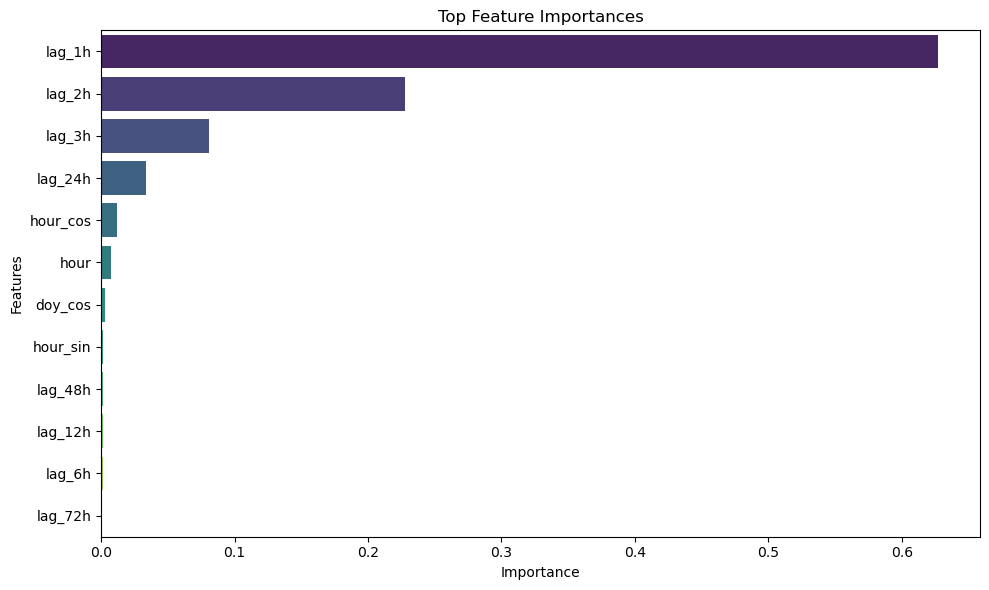

In [11]:
rf_est = best_model
imp = (
    pd.DataFrame({"feature": features, "importance": rf_est.feature_importances_})
    .sort_values("importance", ascending=False)
)
print("\nTop features By Importance:")
print(imp.head(12))

# Permutation importance on validation
perm = permutation_importance(best_model, X_test, y_test,n_repeats=10, random_state=0, n_jobs=-1)
perm_imp = (
    pd.DataFrame({
        "feature": features,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    })
    .sort_values("importance_mean", ascending=False)
)
print("\nTop Features By Permutation Importance (Validation):")
print(perm_imp.head(12))

plt.figure(figsize=(10,6))
sns.barplot(
    data=imp.head(12),
    x="importance",
    y="feature",
    palette="viridis",
    hue='feature',
    legend=False
)
plt.title("Top Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

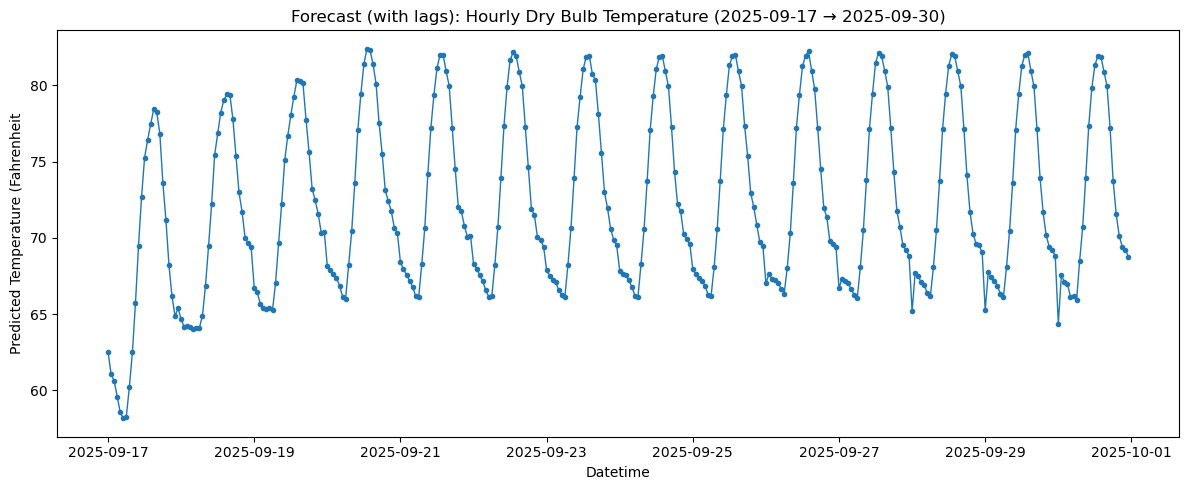

In [12]:
plt.figure(figsize=(12,5))
plt.plot(predictions["ds"], predictions["pred_hourlyDryBulbTemperature"], marker='.', linewidth=1)
plt.title("Forecast (with lags): Hourly Dry Bulb Temperature (2025-09-17 → 2025-09-30)")
plt.xlabel("Datetime")
plt.ylabel("Predicted Temperature (Fahrenheit")
plt.tight_layout()
plt.show()